# DQ Analysis — BDR Readiness Dataset
quick exploratory pass to understand what's broken before scoring

starting with raw files, going issue by issue as i find them

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:


RAW = Path('../data/raw')

leads = pd.read_csv(RAW / 'leads.csv')
print ('leads done')
contacts = pd.read_csv(RAW / 'contacts.csv')
print ('contacts done')

leads done
contacts done


In [3]:
leads.shape

(600, 31)

In [4]:
accounts = pd.read_csv(RAW / 'accounts.csv')
print ('accounts done')

accounts done


In [5]:

campaigns = pd.read_csv(RAW / 'campaigns.csv')
print ('campaigns done')

campaigns done


In [6]:
cm = pd.read_csv(RAW / 'campaign_members.csv')
print ('campaign_members done')

campaign_members done


In [7]:
leads.shape, contacts.shape, accounts.shape, campaigns.shape, cm.shape

((600, 31), (400, 22), (200, 11), (60, 4), (4541, 11))

In [8]:
leads.head(3)

,lead_id,first_name,last_name,email,title,company,job_level,job_persona,phone,account_id,...,no_longer_with_company,is_converted,converted_contact_id,free_email_known,actual_free_email,mkto_lead_score,mql_cycle_count,is_disqualified,dq_reason,dq_date
0,L00001,Richard,Harris,newsletter@marketingblast.com,Unknown Title,NaN,NaN,Non-Prospect: Vendor,+1-555-9331,NaN,...,False,False,NaN,False,False,23,2,False,NaN,NaN
1,L00002,Angela,Young,ayoung@unknown.com,Manager of Something,NaN,Manager,NaN,+1-555-2534,NaN,...,False,False,NaN,False,False,8,0,False,NaN,NaN
2,L00003,Paul,Allen,pallen@quantumgroup.com,Individual Contributor of Something,Quantum Group & Co,Individual Contributor,Influencer,+1-555-5693,ACC0044,...,False,False,NaN,False,False,71,0,False,NaN,NaN


In [9]:
contacts.head(3)

,contact_id,first_name,last_name,email,title,job_level,job_persona,phone,account_id,industry,...,is_mql,mql_date,email_opt_out,email_bounced,is_converted,primary_lead_id,free_email_known,actual_free_email,mkto_contact_score_c,has_lead_origin
0,C00001,Ashley,Anderson,aanderson@unknown.com,Manager of Something,Manager,NaN,+1-555-6512,NaN,NaN,...,False,NaN,False,False,False,L00582,False,False,0.0,True
1,C00002,Sandra,Moore,smoore@aethergroup.com,Director of Something,Director,Technical Buyer,+1-555-4149,ACC0113,Professional Services,...,False,NaN,False,False,False,NaN,False,False,57.9,False
2,C00003,Brian,Gonzalez,bgonzalez@fusionsystems.com,Manager of Something,Manager,Non-Prospect: Competitor,+1-555-5666,ACC0136,Financial Services,...,False,NaN,False,False,False,NaN,False,False,10.5,False


---
## DQ-4 — created_date looks suspicious
noticed a lot of the same date while scrolling. let me check

In [10]:
leads['created_date'].value_counts().head(10)

created_date
2024-01-01    465
2023-01-24      2
2023-08-29      2
2023-01-17      2
2023-12-08      2
2022-05-08      2
2022-08-26      2
2022-10-20      2
2022-06-08      2
2022-02-08      2
Name: count, dtype: int64

In [11]:
# we can see that more than 80% leads have same ETL date which must be the load dat

In [12]:
contacts['created_date'].value_counts().head(10)

created_date
2024-01-01    140
2022-09-14      3
2023-08-20      3
2022-08-20      2
2023-01-17      2
2022-10-19      2
2022-01-08      2
2022-06-22      2
2023-04-04      2
2023-05-10      2
Name: count, dtype: int64

In [13]:
contacts.isna().sum()

contact_id                0
first_name                0
last_name                 0
email                     0
title                    44
job_level                66
job_persona             152
phone                    73
account_id               61
industry                 61
employee_count           61
created_date              0
is_mql                    0
mql_date                278
email_opt_out             0
email_bounced             0
is_converted              0
primary_lead_id         238
free_email_known          0
actual_free_email         0
mkto_contact_score_c      0
has_lead_origin           0
dtype: int64

In [14]:
# Same issue for contacts as well. We can ignore created_date for both leads and contacts as it is not the actual created date but the load date.

In [15]:

etl_date = '2024-01-01'

pct_leads_etl = (leads['created_date'] == etl_date).mean()
pct_contacts_etl = (contacts['created_date'] == etl_date).mean()

print(f'leads with ETL date: {pct_leads_etl:.1%}')
print(f'contacts with ETL date: {pct_contacts_etl:.1%}')

leads with ETL date: 77.5%
contacts with ETL date: 35.0%


<Axes: title={'center': 'Lead created_date distribution (top 5)'}, xlabel='created_date'>

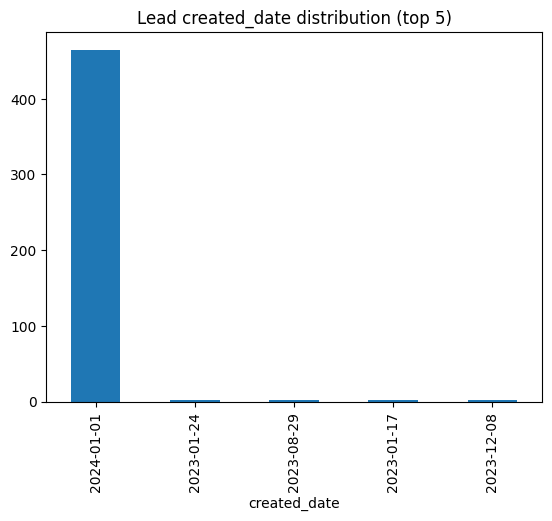

In [16]:
# 80% of leads — this date is completely useless for sequencing or recency logic
# contacts are better (34%) but still bad
# should NOT use created_date for anything in scoring

leads['created_date'].value_counts().nlargest(5).plot(kind='bar', title='Lead created_date distribution (top 5)')

---
## DQ-2 — Duplicate emails
leads and contacts might share emails, or have internal dupes. let me check both

In [17]:
# dupes within leads
lead_email_counts = leads['email'].value_counts()
print('leads with duplicate email:')
print(lead_email_counts[lead_email_counts > 1].head(10))

leads with duplicate email:
email
newsletter@marketingblast.com    13
leads@databroker.io              11
marketing@globalpartners.com      6
info@techconf.com                 5
admin@tradeshow.events            4
snelson@unknown.com               3
sales@enterprisetech.com          3
sales@cloudvendor.io              3
sales@megacorp.com                3
dadams@forgegroup.com             2
Name: count, dtype: int64


In [18]:
leads['lead_id'].nunique(), leads['email'].nunique() 

(600, 537)

In [19]:
duplicate_emails

NameError: name 'duplicate_emails' is not defined

In [20]:
# count of emails with multiple lead_ids
email_lead_counts = leads.groupby('email')['lead_id'].nunique()
duplicate_emails = email_lead_counts[email_lead_counts > 1]
print('Emails associated with multiple lead_ids:', len(duplicate_emails))

Emails associated with multiple lead_ids: 30


In [21]:
# dupes within contacts
contact_email_counts = contacts['email'].value_counts()
print('contacts with duplicate email:')
print(contact_email_counts[contact_email_counts > 1])

contacts with duplicate email:
email
noreply@formspam.net            14
subscribe@vendorblast.com       10
info@b2bleads.net                4
sales@enterprisetech.com         4
slewis@apexpartners.com          2
hello@sdrlists.com               2
admin@tradeshow.events           2
atorres@unknown.com              2
info@securitysummit.org          2
ljohnson@unknown.com             2
contact@vendorlist.net           2
dflores@luminarynetworks.com     2
Name: count, dtype: int64


In [22]:
# cross-object dupes — same email on a lead AND a contact (the conversion case)
all_emails = pd.concat([
    leads[['email']].assign(source='lead'),
    contacts[['email']].assign(source='contact')
])

cross_dupes = all_emails.groupby('email')['source'].nunique()
print(f'emails appearing in both leads AND contacts: {(cross_dupes > 1).sum()}')

emails appearing in both leads AND contacts: 48


In [23]:
# also spot the shared/spam addresses
all_emails_combined = list(leads['email']) + list(contacts['email'])
email_freq = pd.Series(all_emails_combined).value_counts()
print('highest frequency emails (spam/shared):')
print(email_freq[email_freq >= 3].head(10))

highest frequency emails (spam/shared):
noreply@formspam.net             14
newsletter@marketingblast.com    13
leads@databroker.io              11
subscribe@vendorblast.com        10
sales@enterprisetech.com          7
marketing@globalpartners.com      7
info@techconf.com                 6
admin@tradeshow.events            6
snelson@unknown.com               4
sales@cloudvendor.io              4
Name: count, dtype: int64


---
## DQ-6 — Non-prospect contamination + null job_persona
the `true_persona` field tells us who's actually a prospect vs junk

In [24]:
leads.columns

Index(['lead_id', 'first_name', 'last_name', 'email', 'title', 'company',
       'job_level', 'job_persona', 'phone', 'account_id', 'industry',
       'employee_count', 'zi_industry', 'zi_employee_count', 'created_date',
       'lead_source', 'lead_status', 'is_current_mql', 'mql_date',
       'email_opt_out', 'email_bounced', 'no_longer_with_company',
       'is_converted', 'converted_contact_id', 'free_email_known',
       'actual_free_email', 'mkto_lead_score', 'mql_cycle_count',
       'is_disqualified', 'dq_reason', 'dq_date'],
      dtype='str')

In [25]:
leads['job_level'].isna().sum()

np.int64(75)

In [26]:
leads['job_persona'].isna().sum()

np.int64(248)

In [27]:
leads['job_persona'].value_counts()

job_persona
Technical Buyer             67
Non-Prospect: Employee      53
Non-Prospect: Competitor    44
Financial Buyer             44
Influencer                  32
CISO                        30
Non-Prospect: Vendor        28
Non-Prospect: Other         28
Non-Prospect: Partner       26
Name: count, dtype: int64

In [28]:
leads['job_level'].value_counts()

job_level
Individual Contributor    203
Manager                   135
Director                  107
VP                         60
C-Level                    20
Name: count, dtype: int64

In [29]:
contacts['job_persona'].isna().sum()

np.int64(152)

In [30]:
contacts['job_persona'].value_counts()

job_persona
Technical Buyer             55
Financial Buyer             35
Non-Prospect: Employee      32
Non-Prospect: Competitor    31
Non-Prospect: Vendor        22
Non-Prospect: Partner       21
Influencer                  20
Non-Prospect: Other         19
CISO                        13
Name: count, dtype: int64

In [31]:
l['job_persona'].value_counts()

NameError: name 'l' is not defined

In [32]:
# so roughly 38% are non-prospects (partner/competitor/employee/vendor)
# that's a lot of noise in the scoring pool

non_prospect_leads = leads[leads['true_persona'] != 'Prospect']
print(f'non-prospect leads: {len(non_prospect_leads)} ({len(non_prospect_leads)/len(leads):.1%})')

KeyError: 'true_persona'

In [33]:
# now job_persona nulls — this is a separate issue from true_persona
print('job_persona null rate in leads:', leads['job_persona'].isna().mean().round(3))
print('job_persona null rate in contacts:', contacts['job_persona'].isna().mean().round(3))

job_persona null rate in leads: 0.413
job_persona null rate in contacts: 0.38


In [34]:
# ~40% null — way too high to just drop. need to impute or handle carefully
# but NOT with global mean — leads/contacts have different distributions

print('job_persona distribution in leads (non-null):')
print(leads['job_persona'].value_counts(dropna=True))
print()
print('job_persona distribution in contacts (non-null):')
print(contacts['job_persona'].value_counts(dropna=True))

job_persona distribution in leads (non-null):
job_persona
Technical Buyer             67
Non-Prospect: Employee      53
Non-Prospect: Competitor    44
Financial Buyer             44
Influencer                  32
CISO                        30
Non-Prospect: Vendor        28
Non-Prospect: Other         28
Non-Prospect: Partner       26
Name: count, dtype: int64

job_persona distribution in contacts (non-null):
job_persona
Technical Buyer             55
Financial Buyer             35
Non-Prospect: Employee      32
Non-Prospect: Competitor    31
Non-Prospect: Vendor        22
Non-Prospect: Partner       21
Influencer                  20
Non-Prospect: Other         19
CISO                        13
Name: count, dtype: int64


---
## DQ-7 — Missing fields
quick null scan across both tables

In [35]:
key_lead_cols = ['email', 'title', 'phone', 'account_id', 'job_level', 'job_persona', 'industry']
key_contact_cols = ['email', 'title', 'phone', 'account_id', 'job_level', 'job_persona', 'industry']

print('null % — leads')
print(leads[key_lead_cols].isna().mean().mul(100).round(1).sort_values(ascending=False))
print()
print('null % — contacts')
print(contacts[key_contact_cols].isna().mean().mul(100).round(1).sort_values(ascending=False))

null % — leads
job_persona    41.3
phone          18.7
account_id     15.5
industry       15.5
job_level      12.5
title          10.3
email           0.0
dtype: float64

null % — contacts
job_persona    38.0
phone          18.2
job_level      16.5
account_id     15.2
industry       15.2
title          11.0
email           0.0
dtype: float64


In [36]:
# account_id missing means we lose industry + employee_count too — it cascades
no_account_leads = leads['account_id'].isna().sum()
no_account_contacts = contacts['account_id'].isna().sum()
print(f'leads with no account: {no_account_leads} ({no_account_leads/len(leads):.1%})')
print(f'contacts with no account: {no_account_contacts} ({no_account_contacts/len(contacts):.1%})')

leads with no account: 93 (15.5%)
contacts with no account: 61 (15.2%)


In [37]:
# how many leads have no account AND no industry independently
leads['has_any_company_signal'] = leads['account_id'].notna() | leads['industry'].notna()
print('leads with zero company signal:', (~leads['has_any_company_signal']).sum())

leads with zero company signal: 93


---
## DQ-8 — Automation-inflated engagement
some records look very active but it's all 'Sent' status — automated blasts, not real intent

In [38]:
# status distribution overall
print('campaign member_status breakdown:')
print(cm['member_status'].value_counts())
print()
print(f"'Sent' share of all events: {(cm['member_status']=='Sent').mean():.1%}")

campaign member_status breakdown:
member_status
Sent          3025
Clicked        443
Registered     363
Attended       362
No Show        187
Responded      161
Name: count, dtype: int64

'Sent' share of all events: 66.6%


In [39]:
# per-person automation share
person_cm = cm.groupby('entity_id').agg(
    total=('cm_id', 'count'),
    sent=('member_status', lambda x: (x == 'Sent').sum())
).assign(auto_share=lambda df: df['sent'] / df['total'])

print('automation share distribution:')
print(person_cm['auto_share'].describe().round(3))
print()
print(f"records where >70% of events are 'Sent': {(person_cm['auto_share'] > 0.7).sum()} ({(person_cm['auto_share'] > 0.7).mean():.1%})")

automation share distribution:
count    767.000
mean       0.434
std        0.384
min        0.000
25%        0.000
50%        0.333
75%        0.833
max        1.000
Name: auto_share, dtype: float64

records where >70% of events are 'Sent': 258 (33.6%)


In [40]:
person_cm.sort_values('auto_share', ascending=False).head(10)

,total,sent,auto_share
entity_id,,,
C00010,1,1,1.0
L00065,11,11,1.0
L00079,1,1,1.0
L00537,1,1,1.0
L00547,7,7,1.0
C00056,1,1,1.0
L00108,11,11,1.0
L00052,1,1,1.0
L00054,14,14,1.0


In [41]:
# look at the most inflated records
inflated = person_cm[person_cm['auto_share'] > 0.7].sort_values('total', ascending=False)
print('top 10 most inflated records:')
print(inflated.head(10))

top 10 most inflated records:
           total  sent  auto_share
entity_id                         
C00289        45    39    0.866667
C00317        44    36    0.818182
L00288        44    39    0.886364
C00260        43    38    0.883721
C00292        43    38    0.883721
C00103        42    36    0.857143
C00216        42    35    0.833333
L00191        42    39    0.928571
L00343        41    36    0.878049
L00139        41    35    0.853659


In [42]:
# these folks have 10-17 events but almost all 'Sent' — would score very high on naive count
# genuine events per person distribution (excluding Sent)
genuine = cm[cm['member_status'] != 'Sent']
genuine_per_person = genuine.groupby('entity_id').size()

print('genuine (non-Sent) engagement events per person:')
print(genuine_per_person.describe().round(2))
print()
print('people with 0 genuine events:', len(person_cm) - len(genuine_per_person))

genuine (non-Sent) engagement events per person:
count    677.00
mean       2.24
std        1.56
min        1.00
25%        1.00
50%        2.00
75%        3.00
max       12.00
dtype: float64

people with 0 genuine events: 90


---
## DQ-9 — Opted out / bounced / no longer with company
these are hard blockers — can't outreach regardless of score

In [43]:
for col in ['email_opt_out', 'email_bounced']:
    n_leads = leads[col].sum()
    n_contacts = contacts[col].sum()
    print(f'{col}: leads={n_leads} ({n_leads/len(leads):.1%}), contacts={n_contacts} ({n_contacts/len(contacts):.1%})')

email_opt_out: leads=140 (23.3%), contacts=90 (22.5%)
email_bounced: leads=71 (11.8%), contacts=34 (8.5%)


In [44]:
# 'no_longer_with_company' only on leads in this dataset
if 'no_longer_with_company' in leads.columns:
    n = leads['no_longer_with_company'].sum()
    print(f'no_longer_with_company: {n} leads ({n/len(leads):.1%})')

no_longer_with_company: 51 leads (8.5%)


In [45]:
# how many are blocked on MULTIPLE criteria — stacking
leads['blocker_count'] = (
    leads['email_opt_out'].astype(int) +
    leads['email_bounced'].astype(int) +
    leads.get('no_longer_with_company', pd.Series(0, index=leads.index)).astype(int)
)
print('leads by blocker count:')
print(leads['blocker_count'].value_counts().sort_index())

leads by blocker count:
blocker_count
0    370
1    199
2     30
3      1
Name: count, dtype: int64


In [46]:
# check if opted-out records have high engagement scores — would be a problem if we scored without filtering
opted_out_lead_ids = leads[leads['email_opt_out'] == True]['lead_id'].tolist()
opted_out_cm = cm[cm['entity_id'].isin(opted_out_lead_ids)]
print(f'opted-out leads with campaign activity: {opted_out_cm["entity_id"].nunique()}')
print('their event counts:')
print(opted_out_cm.groupby('entity_id').size().describe().round(1))

opted-out leads with campaign activity: 106
their event counts:
count    106.0
mean       5.4
std        6.6
min        1.0
25%        2.0
50%        3.0
75%        8.0
max       42.0
dtype: float64


---
## DQ-1 — Broken conversion links
converted leads that have no matching contact_id — orphaned conversions

In [47]:
converted = leads[leads['is_converted'] == True]
print(f'total converted leads: {len(converted)}')
print(f'of those, missing converted_contact_id: {converted["converted_contact_id"].isna().sum()}')
print(f'broken link rate: {converted["converted_contact_id"].isna().mean():.1%}')

total converted leads: 200
of those, missing converted_contact_id: 38
broken link rate: 19.0%


In [48]:
# even for the ones that DO have a contact_id, does the contact actually exist?
linked_contact_ids = converted['converted_contact_id'].dropna().tolist()
existing_contact_ids = set(contacts['contact_id'])

dangling = [cid for cid in linked_contact_ids if cid not in existing_contact_ids]
print(f'converted leads pointing to non-existent contacts: {len(dangling)}')

converted leads pointing to non-existent contacts: 0


In [49]:
# the reverse — contacts that claim to have a lead origin
if 'primary_lead_id' in contacts.columns:
    has_origin = contacts['primary_lead_id'].notna()
    print(f'contacts with a primary_lead_id: {has_origin.sum()}')
    # do those leads still exist?
    existing_lead_ids = set(leads['lead_id'])
    dangling_contacts = contacts.loc[has_origin, 'primary_lead_id'].apply(lambda x: x not in existing_lead_ids).sum()
    print(f'of those, pointing to missing leads: {dangling_contacts}')

contacts with a primary_lead_id: 162
of those, pointing to missing leads: 0


---
## DQ-3 — MQL date integrity
mql_date should predate or equal conversion. let me check if that holds

In [50]:
mql_leads = leads[leads['is_current_mql'] == True].copy()
print(f'MQL leads: {len(mql_leads)}')
print(f'of those, null mql_date: {mql_leads["mql_date"].isna().sum()}')

MQL leads: 158
of those, null mql_date: 1


In [51]:
# for converted MQL leads, mql_date often gets overwritten with conversion date
# check if mql_date clustering around conversion period
converted_mql = leads[(leads['is_converted'] == True) & (leads['is_current_mql'] == True)].copy()
print(f'leads that are both converted AND MQL: {len(converted_mql)}')
if len(converted_mql) > 0:
    print('\nmql_date distribution for converted MQLs:')
    print(pd.to_datetime(converted_mql['mql_date']).dt.year.value_counts())

leads that are both converted AND MQL: 54

mql_date distribution for converted MQLs:
mql_date
2023    54
Name: count, dtype: int64


In [52]:
# mql_date spread for regular (non-converted) MQLs
non_converted_mql = leads[(leads['is_converted'] == False) & (leads['is_current_mql'] == True)].copy()
print('mql_date distribution for non-converted MQLs:')
print(pd.to_datetime(non_converted_mql['mql_date']).dt.year.value_counts())

mql_date distribution for non-converted MQLs:
mql_date
2022.0    63
2023.0    40
Name: count, dtype: int64


---
## DQ-5 — Competing score fields (Marketo)
leads have `mkto_lead_score` (int), contacts have `mkto_contact_score_c` (float) — different field names, different dtypes

In [53]:
print('mkto_lead_score dtype:', leads['mkto_lead_score'].dtype)
print(leads['mkto_lead_score'].describe().round(1))
print()
print('mkto_contact_score_c dtype:', contacts['mkto_contact_score_c'].dtype)
print(contacts['mkto_contact_score_c'].describe().round(1))

mkto_lead_score dtype: int64
count    600.0
mean      44.3
std       31.3
min        0.0
25%       14.0
50%       46.0
75%       71.0
max       99.0
Name: mkto_lead_score, dtype: float64

mkto_contact_score_c dtype: float64
count    400.0
mean      42.7
std       30.9
min        0.0
25%       14.7
50%       39.6
75%       71.4
max       99.1
Name: mkto_contact_score_c, dtype: float64


In [54]:
# DQ-10: score resets — check zero inflation
print(f'leads with mkto score = 0: {(leads["mkto_lead_score"] == 0).sum()} ({(leads["mkto_lead_score"] == 0).mean():.1%})')
print(f'contacts with mkto score = 0: {(contacts["mkto_contact_score_c"] == 0).sum()} ({(contacts["mkto_contact_score_c"] == 0).mean():.1%})')

leads with mkto score = 0: 68 (11.3%)
contacts with mkto score = 0: 47 (11.8%)


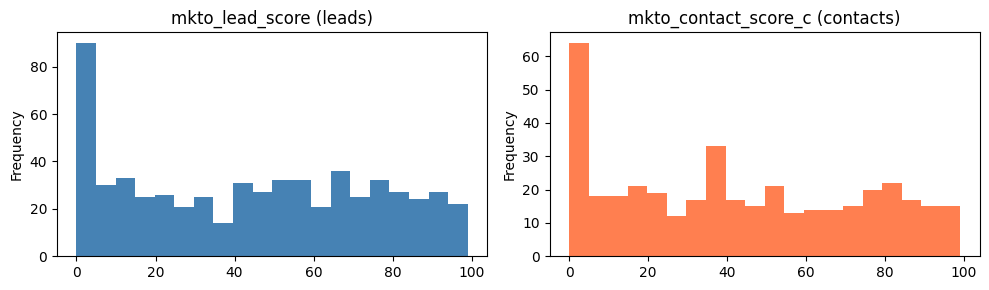

In [55]:
# score distribution — are these even comparable?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
leads['mkto_lead_score'].plot(kind='hist', bins=20, ax=axes[0], title='mkto_lead_score (leads)', color='steelblue')
contacts['mkto_contact_score_c'].plot(kind='hist', bins=20, ax=axes[1], title='mkto_contact_score_c (contacts)', color='coral')
plt.tight_layout()
plt.show()
# they look roughly similar but zero-inflated — the reset problem

---
## DQ-11 — Free email leakage
the `free_email_known` flag should detect free domains (gmail, yahoo etc.) but it misses some

In [56]:
FREE_DOMAINS = {'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'protonmail.com'}

leads['actual_free_detected'] = leads['email'].apply(lambda e: str(e).split('@')[-1].lower() in FREE_DOMAINS)
contacts['actual_free_detected'] = contacts['email'].apply(lambda e: str(e).split('@')[-1].lower() in FREE_DOMAINS)

print('=== leads ===')
print('actually free email:  ', leads['actual_free_detected'].sum())
print('flagged as free (known):', leads['free_email_known'].sum())
print('missed (free but not flagged):', (leads['actual_free_detected'] & ~leads['free_email_known']).sum())

=== leads ===
actually free email:   51
flagged as free (known): 33
missed (free but not flagged): 22


In [57]:
print('=== contacts ===')
print('actually free email:  ', contacts['actual_free_detected'].sum())
print('flagged as free (known):', contacts['free_email_known'].sum())
print('missed (free but not flagged):', (contacts['actual_free_detected'] & ~contacts['free_email_known']).sum())

=== contacts ===
actually free email:   21
flagged as free (known): 19
missed (free but not flagged): 3


In [58]:
# see which domains are slipping through
missed_leads = leads[leads['actual_free_detected'] & ~leads['free_email_known']]
print('missed free-email domains in leads:')
print(missed_leads['email'].apply(lambda e: e.split('@')[-1]).value_counts())

missed free-email domains in leads:
email
hotmail.com       6
gmail.com         5
protonmail.com    4
outlook.com       4
yahoo.com         3
Name: count, dtype: int64


---
## DQ quick summary — how many records are affected by each issue

In [60]:
all_people = pd.concat([
    leads.assign(entity_type='Lead', record_id=leads['lead_id']),
    contacts.assign(entity_type='Contact', record_id=contacts['contact_id'])
], ignore_index=True)

total = len(all_people)

dq_summary = [
    ('DQ-1  broken conversion link',   converted['converted_contact_id'].isna().sum()),
    ('DQ-2  duplicate email',          all_people['email'].duplicated(keep=False).sum()),
    ('DQ-4  ETL created_date',         (all_people['created_date'] == etl_date).sum()),
    ('DQ-5  score field = 0 (reset)',  int(leads['mkto_lead_score'].eq(0).sum()) + int(contacts['mkto_contact_score_c'].eq(0).sum())),
    #('DQ-6  non-prospect in pool',     (all_people['true_persona'] != 'Prospect').sum()),
    ('DQ-6  null job_persona',         all_people['job_persona'].isna().sum()),
    ('DQ-7  missing account_id',       all_people['account_id'].isna().sum()),
    ('DQ-8  automation-inflated >70%', int((person_cm['auto_share'] > 0.7).sum())),
    ('DQ-9  opt-out or bounced',       int(all_people['email_opt_out'].sum() + all_people['email_bounced'].sum())),
    ('DQ-11 free email missed',        int((leads['actual_free_detected'] & ~leads['free_email_known']).sum() +
                                          (contacts['actual_free_detected'] & ~contacts['free_email_known']).sum())),
]

df_summary = pd.DataFrame(dq_summary, columns=['Issue', 'Affected Records'])
df_summary['% of Total'] = (df_summary['Affected Records'] / total * 100).round(1).astype(str) + '%'
df_summary

,Issue,Affected Records,% of Total
0,DQ-1 broken conversion link,38,3.8%
1,DQ-2 duplicate email,220,22.0%
2,DQ-4 ETL created_date,605,60.5%
3,DQ-5 score field = 0 (reset),115,11.5%
4,DQ-6 null job_persona,400,40.0%
5,DQ-7 missing account_id,154,15.4%
6,DQ-8 automation-inflated >70%,258,25.8%
7,DQ-9 opt-out or bounced,335,33.5%
8,DQ-11 free email missed,25,2.5%


---
## a few extra checks I want to do before closing
just random things that caught my eye

In [61]:
# are leads and contacts going to the same campaigns? i.e. is campaign_members mixed
print('entity types in campaign_members:')
print(cm['entity_type'].value_counts())

entity types in campaign_members:
entity_type
Lead       2776
Contact    1765
Name: count, dtype: int64


In [62]:
# any campaign_members with entity_id that doesn't exist in either leads or contacts
all_ids = set(leads['lead_id']) | set(contacts['contact_id'])
orphan_cm = cm[~cm['entity_id'].isin(all_ids)]
print(f'campaign_members with no matching person: {len(orphan_cm)}')

campaign_members with no matching person: 0


In [63]:
# how many people have ZERO campaign history at all
people_with_cm = set(cm['entity_id'])
lead_no_cm = (~leads['lead_id'].isin(people_with_cm)).sum()
contact_no_cm = (~contacts['contact_id'].isin(people_with_cm)).sum()
print(f'leads with no campaign history: {lead_no_cm} ({lead_no_cm/len(leads):.1%})')
print(f'contacts with no campaign history: {contact_no_cm} ({contact_no_cm/len(contacts):.1%})')
# these will all get engagement_score=0 — valid but worth noting for the scoring model

leads with no campaign history: 144 (24.0%)
contacts with no campaign history: 89 (22.2%)


In [64]:
# named accounts — do they skew industry?
named_accs = accounts[accounts['is_named_account'] == True]
print('named account industry distribution:')
print(named_accs['industry'].value_counts())

named account industry distribution:
industry
Manufacturing            9
Energy                   7
Government               6
Financial Services       6
Professional Services    5
Healthcare               4
Telecommunications       4
Software                 3
Retail                   2
Education                1
Name: count, dtype: int64


In [65]:
# also check account DNC — how many leads/contacts are at DNC accounts
dnc_account_ids = set(accounts[accounts['account_do_not_contact'] == True]['account_id'])
leads_at_dnc = leads['account_id'].isin(dnc_account_ids).sum()
contacts_at_dnc = contacts['account_id'].isin(dnc_account_ids).sum()
print(f'leads at DNC accounts: {leads_at_dnc}')
print(f'contacts at DNC accounts: {contacts_at_dnc}')

leads at DNC accounts: 24
contacts at DNC accounts: 21
